In [1]:
import numpy as np
from mpasdiag import MPAS3DProcessor
from mpasdiag import (
    MPASVerticalCrossSectionPlotter, CrossSectionStyle,
)

In [2]:
proc = MPAS3DProcessor(grid_file="../data/grids/x1.10242.static.nc", verbose=True)
proc.load_3d_data("../data/u240k/mpasout")

In [3]:
start_point = (-90.0, 29.0)     # (lon, lat)
end_point   = (-79.0, 44.0)

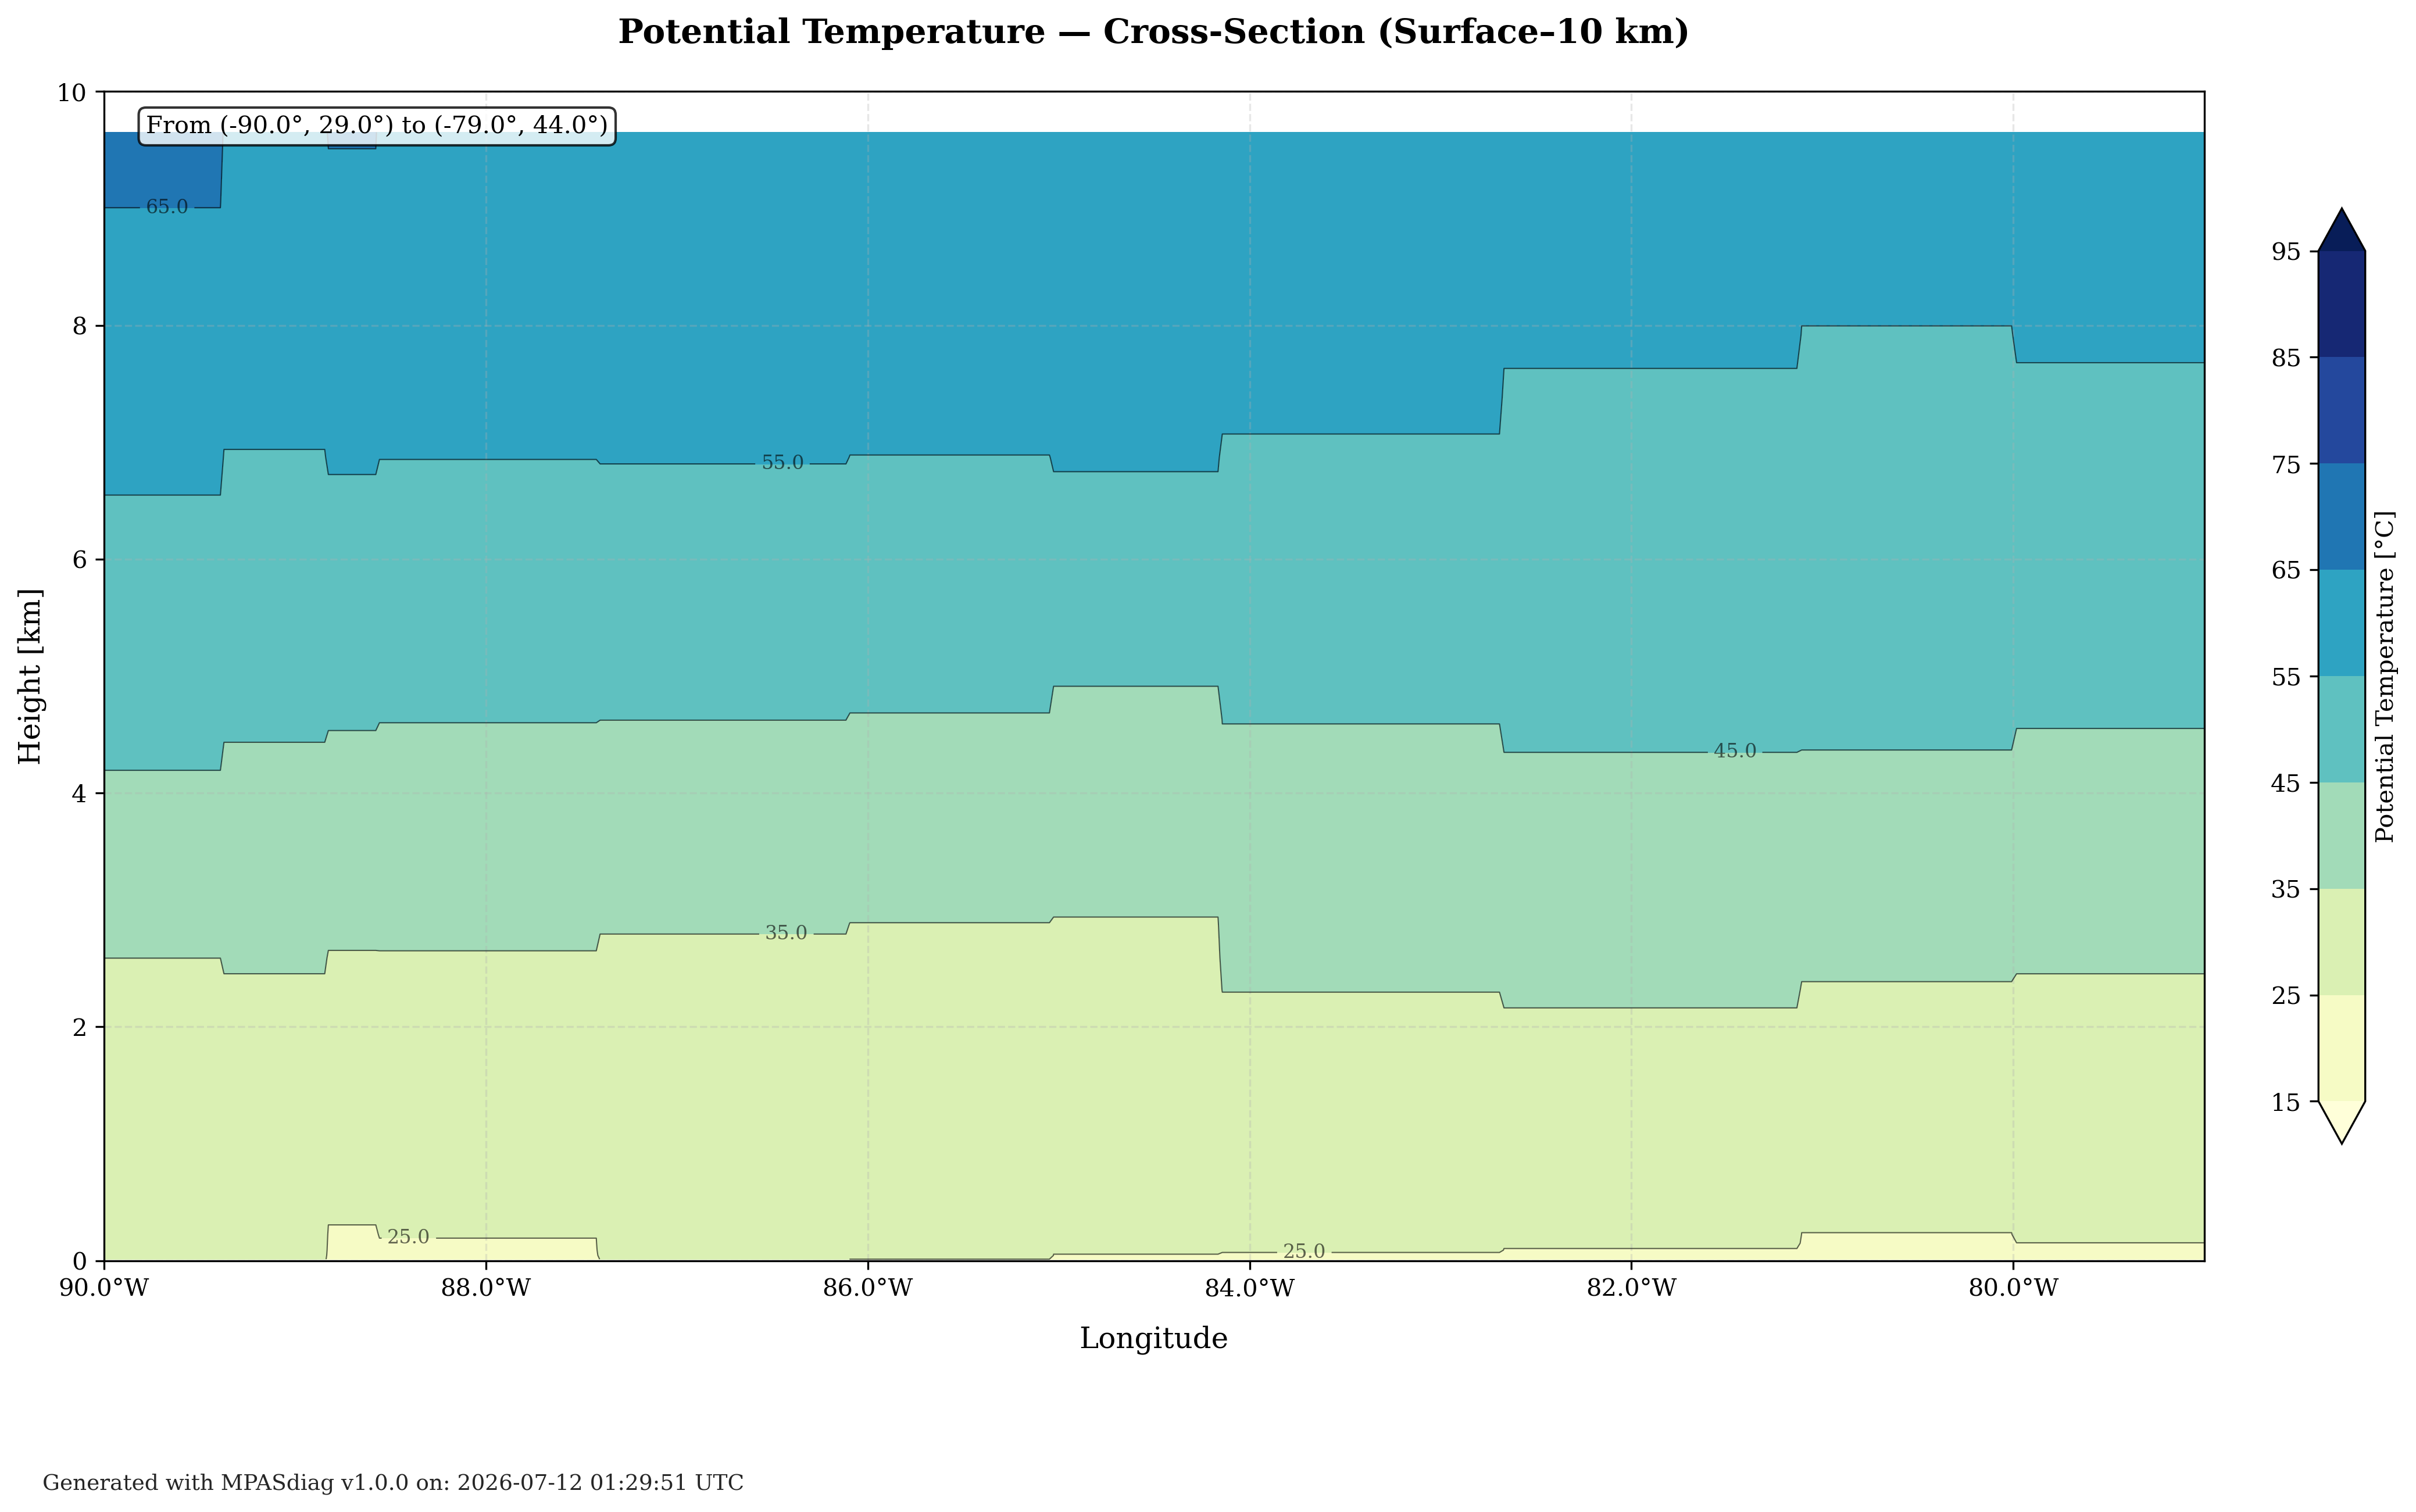

In [4]:
plotter = MPASVerticalCrossSectionPlotter(figsize=(14, 8), dpi=300)
fig, ax = plotter.create_vertical_cross_section(
    mpas_3d_processor=proc,
    var_name="theta",
    start_point=start_point,
    end_point=end_point,
    time_index=1,
    vertical_coord="pressure",   # interpolate in pressure
    display_vertical="height",   # but show a height axis
    max_height=10.0,             # cap at 10 km
    num_points=500,              # samples along the transect
    title="Potential Temperature — Cross-Section (Surface–10 km)",
    style=CrossSectionStyle(levels=np.arange(15, 100, 10),
                            colormap="YlGnBu", extend="both", plot_type="contourf"),
)

In [5]:
plotter.save_plot("./output/theta_cross_section", formats=["png"])
